betül danışmaz


In [1]:

import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:

yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')

print('Data source import complete.')


100%|██████████| 7.11M/7.11M [00:01<00:00, 5.29MB/s]

Extracting files...


Data source import complete.


In [3]:
import os
import shutil

# Define destination directory
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)

# Copy files from kagglehub cache to /content
print(f"Copying files from {yzta_2026_datathon_path} to {dest_dir}...")
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)

# List contents of the new directory to verify
print(f"\nContents of {dest_dir}:")
print(os.listdir(dest_dir))

# Update path variable for subsequent steps
yzta_2026_datathon_path = dest_dir

Copying files from /root/.cache/kagglehub/competitions/yzta-2026-datathon to /content/yzta-2026-datathon...

Contents of /content/yzta-2026-datathon:
['train.csv', 'sample_submission.csv', 'test_x.csv']


In [4]:
import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['train.csv', 'sample_submission.csv', 'test_x.csv']


In [5]:
import pandas as pd
import numpy as np

train_path = os.path.join(data_path, "train.csv")
test_path = os.path.join(data_path, "test_x.csv")
submission_path = os.path.join(data_path, "sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


In [7]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


In [8]:
target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

In [11]:
train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


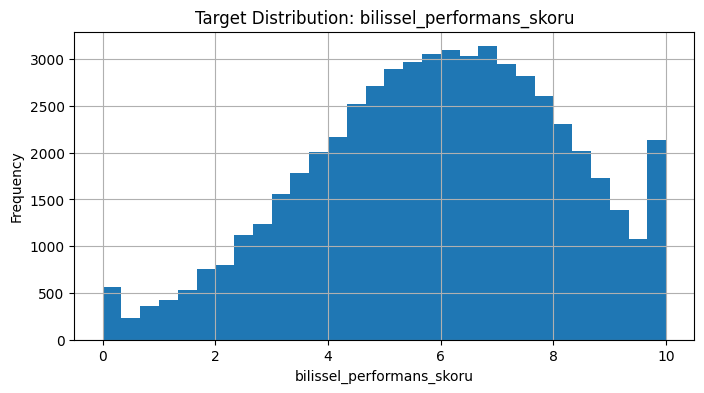

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

In [13]:
target = 'bilissel_performans_skoru'
id_col = 'id'

# Correctly separate X and y using only our identified feature columns
X = train[feature_cols]
y = train[target]

# Check missing values
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test = test.isnull().sum().sort_values(ascending=False)

print('Missing values in train:')
display(missing_train[missing_train > 0])

print('\nMissing values in test:')
display(missing_test[missing_test > 0])

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504


In [15]:
# Final feature identification
target = "bilissel_performans_skoru"
id_col = "id"

# Exclude columns that must not be used as model inputs
feature_cols = [col for col in train.columns if col not in [target, id_col]]

# Separate features by data type
numeric_features = train[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Total features identified: {len(feature_cols)}")
print(f"Numerical features ({len(numeric_features)}):")
print(numeric_features)

print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

Total features identified: 22
Numerical features (15):
['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']

Categorical features (7):
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


In [16]:
# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


In [17]:
print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


In [20]:
print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ensure feature lists are clean
target = "bilissel_performans_skoru"
id_col = "id"
feature_cols = [col for col in train.columns if col not in [target, id_col]]

numeric_features = train[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# Define X and y
X = train[feature_cols]
y = train[target]

# Prepare final test set features
X_test_final = test[feature_cols]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Final test features shape: {X_test_final.shape}")

X shape: (56000, 22)
y shape: (56000,)
Final test features shape: (24000, 22)


In [27]:
from sklearn.model_selection import train_test_split

# Perform the split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (44800, 22)
X_valid shape: (11200, 22)
y_train shape: (44800,)
y_valid shape: (11200,)


In [28]:
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # Support for older scikit-learn versions
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Numeric transformation pipeline: Impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformation pipeline: Impute with mode, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


CATBOOST VS LIGHTGBM

In [35]:
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_predictions(y_true, preds, model_name="model"):
    preds = np.clip(preds, 0, 10)

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print(f"{model_name}")
    print(f"MAE : {mae:.5f}")
    print(f"RMSE: {rmse:.5f}")
    print(f"R2  : {r2:.5f}")

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [44]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 1. Re-evaluate LightGBM without warnings
lgbm_model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.02,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", lgbm_model)])
lgbm_pipe.fit(X_train, y_train)
lgbm_valid_preds = lgbm_pipe.predict(X_valid)
lgbm_result = evaluate_predictions(y_valid, lgbm_valid_preds, model_name="LightGBM")

# 2. Re-evaluate CatBoost using the pipeline-friendly approach
# Note: CatBoost can handle categorical features natively, but for the baseline
# comparison, we'll use the same preprocessed features as LightGBM/HGBR.
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=0,
    allow_writing_files=False
)

cat_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", cat_model)])
cat_pipe.fit(X_train, y_train)
cat_valid_preds = cat_pipe.predict(X_valid)
cat_result = evaluate_predictions(y_valid, cat_valid_preds, model_name="CatBoost (via Pipeline)")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM
MAE : 0.98446
RMSE: 1.22729
R2  : 0.70002
CatBoost (via Pipeline)
MAE : 0.97958
RMSE: 1.22192
R2  : 0.70264


In [46]:
from catboost import CatBoostRegressor

X_cat = X.copy()

# CatBoost needs categorical missing values as strings
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("Missing")

X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(
    X_cat,
    y,
    test_size=0.2,
    random_state=42
)

cat_feature_indices = [
    X_cat.columns.get_loc(col) for col in categorical_features
]

cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=4,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cat, y_valid_cat),
    use_best_model=True,
    early_stopping_rounds=80
)

cat_valid_preds = cat_model.predict(X_valid_cat)

cat_result = evaluate_predictions(
    y_valid_cat,
    cat_valid_preds,
    model_name="CatBoost"
)

0:	learn: 2.1942302	test: 2.2053970	best: 2.2053970 (0)	total: 47.4ms	remaining: 37.9s
100:	learn: 1.2953719	test: 1.3039923	best: 1.3039923 (100)	total: 3.59s	remaining: 24.9s
200:	learn: 1.2308931	test: 1.2462032	best: 1.2462032 (200)	total: 8.19s	remaining: 24.4s
300:	learn: 1.2127838	test: 1.2323615	best: 1.2323615 (300)	total: 12.1s	remaining: 20.1s
400:	learn: 1.2031123	test: 1.2267422	best: 1.2267422 (400)	total: 15.7s	remaining: 15.6s
500:	learn: 1.1956265	test: 1.2242253	best: 1.2241933 (492)	total: 19.6s	remaining: 11.7s
600:	learn: 1.1899629	test: 1.2227689	best: 1.2227689 (600)	total: 23.8s	remaining: 7.89s
700:	learn: 1.1851308	test: 1.2220836	best: 1.2220836 (700)	total: 27.2s	remaining: 3.85s
799:	learn: 1.1807297	test: 1.2216898	best: 1.2216757 (795)	total: 30.6s	remaining: 0us

bestTest = 1.221675711
bestIteration = 795

Shrink model to first 796 iterations.
CatBoost
MAE : 0.97888
RMSE: 1.22150
R2  : 0.70285


In [48]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd

X_cat = X.copy()

for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)

cat_feature_indices = [
    X_cat.columns.get_loc(col) for col in categorical_features
]

print("X_cat shape:", X_cat.shape)
print("Number of categorical features:", len(cat_feature_indices))

X_cat shape: (56000, 22)
Number of categorical features: 7


In [49]:
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx]
        X_val = X_data.iloc[valid_idx]
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=42,
            allow_writing_files=False,
            verbose=0,
            thread_count=4,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_features,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        preds = model.predict(X_val)
        preds = np.clip(preds, 0, 10)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        mae = mean_absolute_error(y_val, preds)
        r2 = r2_score(y_val, preds)

        fold_results.append({
            "fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "best_iteration": model.get_best_iteration()
        })

        print(f"Fold {fold} RMSE: {rmse:.5f}")

    results_df = pd.DataFrame(fold_results)

    print("\nMean CV RMSE:", results_df["RMSE"].mean())
    print("Std CV RMSE :", results_df["RMSE"].std())
    print("Mean CV MAE :", results_df["MAE"].mean())
    print("Mean CV R2  :", results_df["R2"].mean())

    return results_df

In [50]:
catboost_base_params = {
    "iterations": 800,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 4
}

catboost_base_cv = evaluate_catboost_cv(
    params=catboost_base_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

display(catboost_base_cv)

Fold 1 RMSE: 1.22202
Fold 2 RMSE: 1.21703
Fold 3 RMSE: 1.20195
Fold 4 RMSE: 1.20957
Fold 5 RMSE: 1.23237

Mean CV RMSE: 1.2165870806086647
Std CV RMSE : 0.011642088947747934
Mean CV MAE : 0.9710413010259824
Mean CV R2  : 0.7028133238867268


,fold,RMSE,MAE,R2,best_iteration
0,1,1.222017,0.979325,0.702592,798
1,2,1.217028,0.970581,0.700599,797
2,3,1.201949,0.960899,0.709715,778
3,4,1.209574,0.963622,0.704070,771
4,5,1.232367,0.980780,0.697092,792


In [51]:
catboost_candidates = {
    "cat_base_800": {
        "iterations": 800,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 4
    },

    "cat_1200_lr0025_depth6": {
        "iterations": 1200,
        "learning_rate": 0.025,
        "depth": 6,
        "l2_leaf_reg": 4
    },

    "cat_1600_lr002_depth6_reg6": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 6
    },

    "cat_2000_lr0015_depth6_reg8": {
        "iterations": 2000,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_1200_lr0025_depth5_reg4": {
        "iterations": 1200,
        "learning_rate": 0.025,
        "depth": 5,
        "l2_leaf_reg": 4
    },

    "cat_1600_lr002_depth7_reg10": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 7,
        "l2_leaf_reg": 10
    },

    "cat_1600_lr002_depth6_reg10_random": {
        "iterations": 1600,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 10,
        "random_strength": 1.0,
        "bagging_temperature": 0.5
    }
}

In [52]:
tuning_results = []

for name, params in catboost_candidates.items():
    print(f"\nEvaluating: {name}")

    cv_df = evaluate_catboost_cv(
        params=params,
        X_data=X_cat,
        y_data=y,
        cat_features=cat_feature_indices,
        n_splits=3
    )

    tuning_results.append({
        "model": name,
        "mean_rmse": cv_df["RMSE"].mean(),
        "std_rmse": cv_df["RMSE"].std(),
        "mean_mae": cv_df["MAE"].mean(),
        "mean_r2": cv_df["R2"].mean(),
        "mean_best_iteration": cv_df["best_iteration"].mean()
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values("mean_rmse")
display(tuning_results_df)


Evaluating: cat_base_800
Fold 1 RMSE: 1.22432
Fold 2 RMSE: 1.20318
Fold 3 RMSE: 1.22609

Mean CV RMSE: 1.2178640817736923
Std CV RMSE : 0.01274419334057934
Mean CV MAE : 0.9720559282034967
Mean CV R2  : 0.7021810691123278

Evaluating: cat_1200_lr0025_depth6
Fold 1 RMSE: 1.22386
Fold 2 RMSE: 1.20286
Fold 3 RMSE: 1.22567

Mean CV RMSE: 1.2174649182966562
Std CV RMSE : 0.01267872034101938
Mean CV MAE : 0.9715460558656545
Mean CV R2  : 0.7023764717765334

Evaluating: cat_1600_lr002_depth6_reg6
Fold 1 RMSE: 1.22336
Fold 2 RMSE: 1.20320
Fold 3 RMSE: 1.22511

Mean CV RMSE: 1.2172211236006258
Std CV RMSE : 0.012177703431413254
Mean CV MAE : 0.971423450002408
Mean CV R2  : 0.7024971791147095

Evaluating: cat_2000_lr0015_depth6_reg8
Fold 1 RMSE: 1.22308
Fold 2 RMSE: 1.20251
Fold 3 RMSE: 1.22561

Mean CV RMSE: 1.2170650770285594
Std CV RMSE : 0.012670644932101773
Mean CV MAE : 0.9714959273820086
Mean CV R2  : 0.702572213874541

Evaluating: cat_1200_lr0025_depth5_reg4
Fold 1 RMSE: 1.22356
Fold 2 

,model,mean_rmse,std_rmse,mean_mae,mean_r2,mean_best_iteration
3,cat_2000_lr0015_depth6_reg8,1.217065,0.012671,0.971496,0.702572,1953.333333
2,cat_1600_lr002_depth6_reg6,1.217221,0.012178,0.971423,0.702497,1417.333333
6,cat_1600_lr002_depth6_reg10_random,1.217310,0.012472,0.971501,0.702453,1569.000000
4,cat_1200_lr0025_depth5_reg4,1.217338,0.012999,0.971583,0.702438,1188.666667
1,cat_1200_lr0025_depth6,1.217465,0.012679,0.971546,0.702376,1064.666667
5,cat_1600_lr002_depth7_reg10,1.217654,0.012644,0.971884,0.702284,1490.333333
0,cat_base_800,1.217864,0.012744,0.972056,0.702181,795.666667
